Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
First five rows of the dataset:
         X1        X2        X3         Y
0  0.000000  3.440000  0.440000  4.387545
1  0.040404  0.134949  0.888485  2.679650
2  0.080808  0.829899  1.336970  2.968490
3  0.121212  1.524848  1.785455  3.254065
4  0.161616  2.219798  2.233939  3.536375


LEARNING RATE RESULTS

X1:
alpha = 0.10 | Loss = 0.984993 | Iterations = 941 | theta0 = 5.927949 | theta1 = -2.038337
alpha = 0.05 | Loss = 0.984993 | Iterations = 1829 | theta0 = 5.927949 | theta1 = -2.038337
alpha = 0.03 | Loss = 0.984993 | Iterations = 2977 | theta0 = 5.927949 | theta1 = -2.038337
alpha = 0.01 | Loss = 0.984993 | Iterations = 8453 | theta0 = 5.927949 | theta1 = -2.038337

X2:
alpha = 0.10 | Loss = 3.599366 | Iterations = 827 | theta0 = 0.736060 | theta1 = 0.557608
alpha = 0.05 | Loss = 3.599366 | Iterations = 1599 | theta0 = 0.736060 | theta1 = 0.557608
alpha

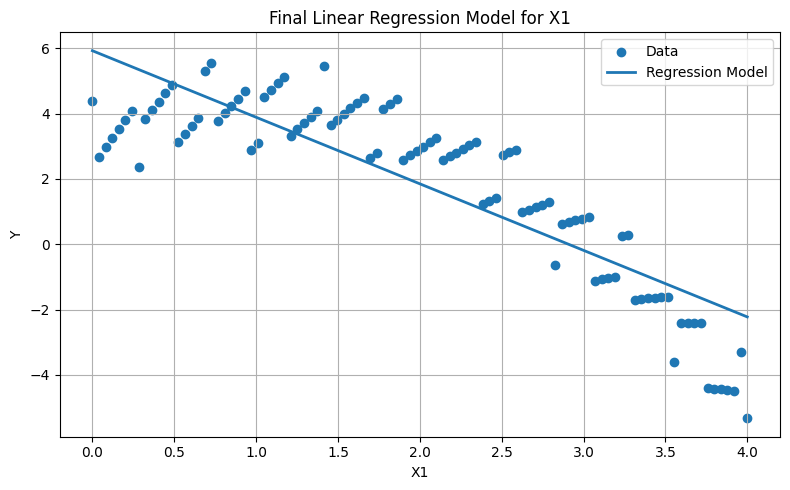

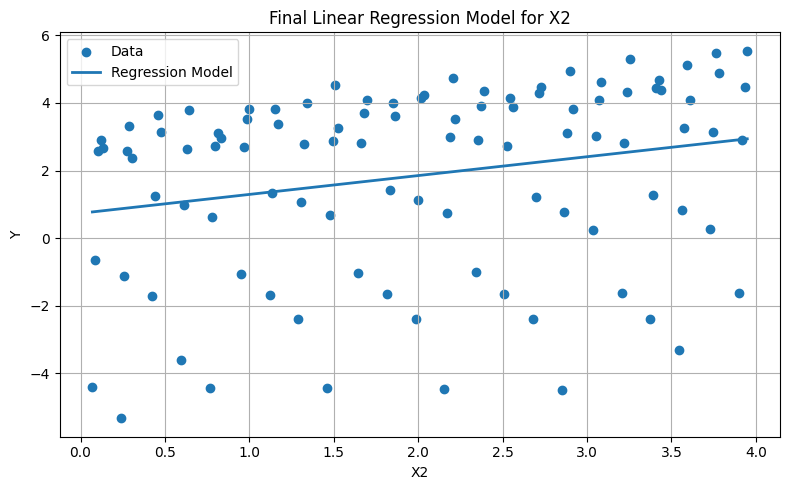

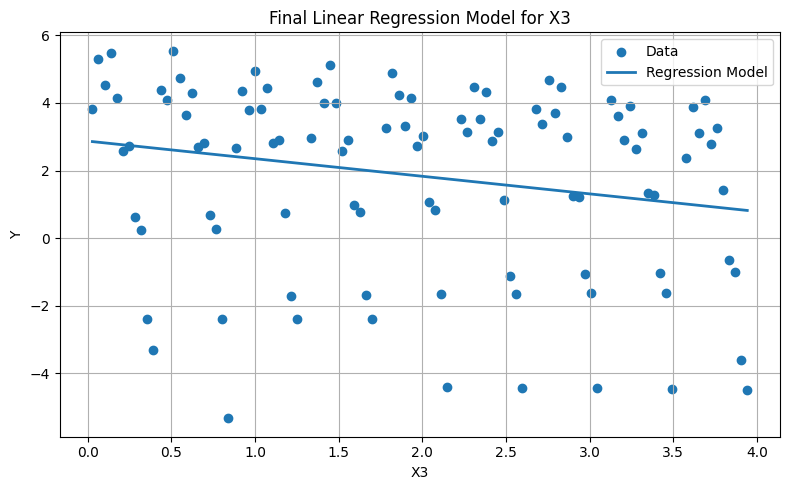

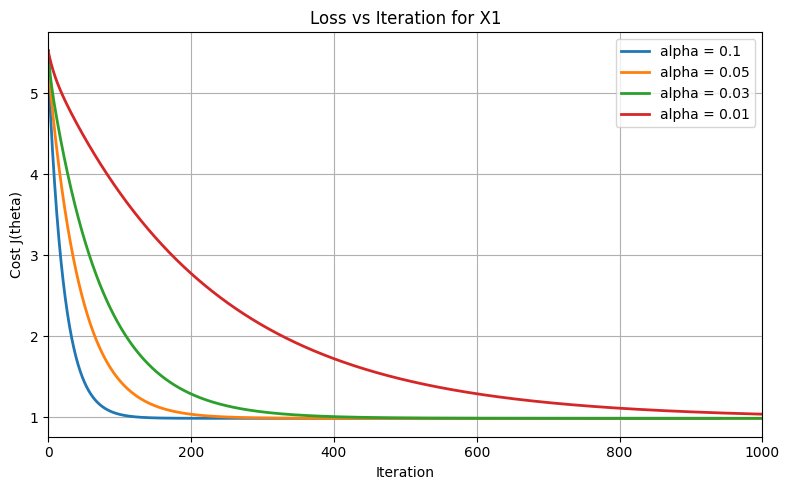

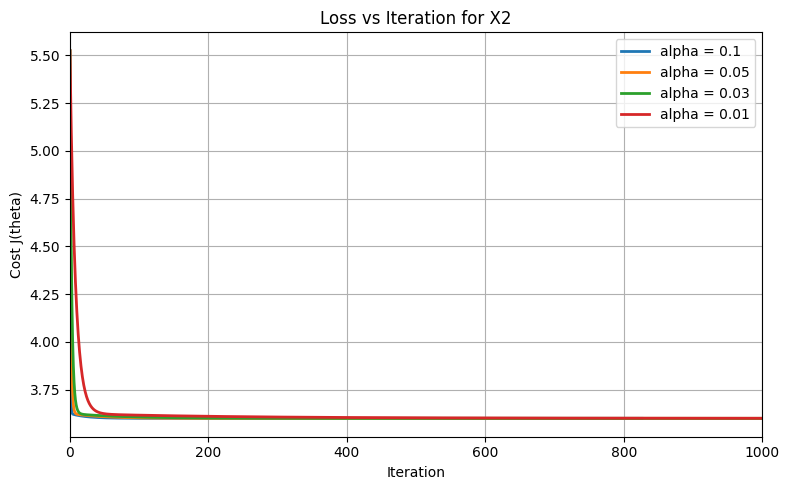

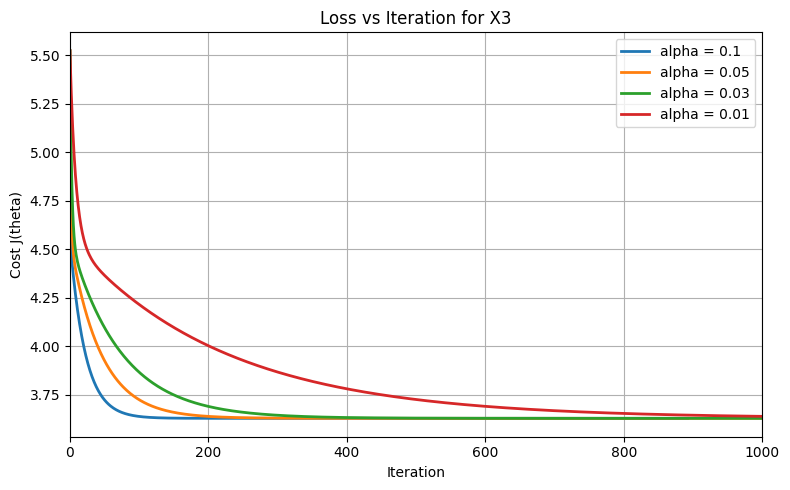



LOWEST LOSS
The explanatory variable with the lowest loss is X1.
Final loss = 0.984993


LEARNING RATE OBSERVATIONS

X1:
alpha = 0.10: Final Loss = 0.984993, Iterations = 941
alpha = 0.05: Final Loss = 0.984993, Iterations = 1829
alpha = 0.03: Final Loss = 0.984993, Iterations = 2977
alpha = 0.01: Final Loss = 0.984993, Iterations = 8453

X2:
alpha = 0.10: Final Loss = 3.599366, Iterations = 827
alpha = 0.05: Final Loss = 3.599366, Iterations = 1599
alpha = 0.03: Final Loss = 3.599366, Iterations = 2593
alpha = 0.01: Final Loss = 3.599366, Iterations = 7299

X3:
alpha = 0.10: Final Loss = 3.629451, Iterations = 893
alpha = 0.05: Final Loss = 3.629451, Iterations = 1734
alpha = 0.03: Final Loss = 3.629451, Iterations = 2820
alpha = 0.01: Final Loss = 3.629451, Iterations = 7989


In [4]:


# ============================================================
# 1. IMPORT LIBRARIES AND MOUNT GOOGLE DRIVE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')


# ============================================================
# 2. LOAD DATA
# ============================================================

file_path = "/content/drive/MyDrive/ML Dataset/D3.csv"

df = pd.read_csv(file_path)

print("First five rows of the dataset:")
print(df.head())


# ============================================================
# 3. EXTRACT X1, X2, X3, AND Y
# ============================================================

X1 = df.iloc[:, 0].values.astype(float)
X2 = df.iloc[:, 1].values.astype(float)
X3 = df.iloc[:, 2].values.astype(float)
Y  = df.iloc[:, 3].values.astype(float)

m = len(Y)


# ============================================================
# 4. COST FUNCTION
#
# J(theta) = (1 / 2m) * sum((y_hat - y)^2)
# ============================================================

def compute_cost(X, y, theta):

    m = len(y)

    predictions = X @ theta

    errors = predictions - y

    cost = (1 / (2 * m)) * np.sum(errors ** 2)

    return cost


# ============================================================
# 5. GRADIENT DESCENT FROM SCRATCH
#
# theta := theta - alpha * gradient
#
# Parameters are initialized to zero
# ============================================================

def gradient_descent(X, y, alpha, max_iterations=20000, tolerance=1e-10):

    m = len(y)

    # Initialize theta0 and theta1 to zero
    theta = np.zeros(X.shape[1])

    loss_history = []

    for iteration in range(max_iterations):

        # Calculate predictions
        predictions = X @ theta

        # Calculate errors
        errors = predictions - y

        # Calculate current loss
        loss = (1 / (2 * m)) * np.sum(errors ** 2)

        loss_history.append(loss)

        # Calculate gradient
        gradient = (1 / m) * (X.T @ errors)

        # Update theta
        new_theta = theta - alpha * gradient

        # Stop when theta changes by a very small amount
        if np.linalg.norm(new_theta - theta) < tolerance:

            theta = new_theta
            break

        theta = new_theta

    return theta, np.array(loss_history), iteration + 1


# ============================================================
# 6. LEARNING RATES TO EXPLORE
# ============================================================

learning_rates = [0.10, 0.05, 0.03, 0.01]


# ============================================================
# 7. STORE THE THREE EXPLANATORY VARIABLES
# ============================================================

variables = {
    "X1": X1,
    "X2": X2,
    "X3": X3
}


results = {}


# ============================================================
# 8. TRAIN THREE SEPARATE LINEAR REGRESSION MODELS
# ============================================================

for variable_name, x in variables.items():

    # Add a column of ones for theta0
    #
    # Model:
    # Y_hat = theta0 + theta1*x

    X_design = np.column_stack((np.ones(m), x))

    results[variable_name] = {}

    for alpha in learning_rates:

        theta, loss_history, iterations = gradient_descent(
            X_design,
            Y,
            alpha
        )

        final_loss = compute_cost(
            X_design,
            Y,
            theta
        )

        results[variable_name][alpha] = {
            "theta": theta,
            "loss_history": loss_history,
            "iterations": iterations,
            "final_loss": final_loss
        }


# ============================================================
# 9. REPORT EFFECT OF DIFFERENT LEARNING RATES
# ============================================================

print("\n")
print("=" * 70)
print("LEARNING RATE RESULTS")
print("=" * 70)


for variable_name in variables:

    print(f"\n{variable_name}:")

    for alpha in learning_rates:

        result = results[variable_name][alpha]

        theta = result["theta"]

        print(
            f"alpha = {alpha:.2f} | "
            f"Loss = {result['final_loss']:.6f} | "
            f"Iterations = {result['iterations']} | "
            f"theta0 = {theta[0]:.6f} | "
            f"theta1 = {theta[1]:.6f}"
        )


# ============================================================
# 10. SELECT A LEARNING RATE FOR THE FINAL MODELS
#
# alpha = 0.10 is used because it converges faster while
# reaching approximately the same final minimum loss.
# ============================================================

selected_alpha = 0.10


# ============================================================
# 11. REPORT FINAL LINEAR MODEL FOR EACH VARIABLE
# ============================================================

print("\n")
print("=" * 70)
print("FINAL LINEAR MODELS")
print("=" * 70)


for variable_name in variables:

    result = results[variable_name][selected_alpha]

    theta = result["theta"]

    print(
        f"\n{variable_name}:"
    )

    print(
        f"Y_hat = {theta[0]:.6f} + ({theta[1]:.6f}){variable_name}"
    )

    print(
        f"Final Loss = {result['final_loss']:.6f}"
    )


# ============================================================
# 12. PLOT FINAL REGRESSION MODEL FOR EACH VARIABLE
# ============================================================

for variable_name, x in variables.items():

    result = results[variable_name][selected_alpha]

    theta = result["theta"]

    # Sort x so that the regression line is drawn smoothly
    order = np.argsort(x)

    x_sorted = x[order]

    y_predicted = theta[0] + theta[1] * x_sorted


    plt.figure(figsize=(8, 5))

    # Original data
    plt.scatter(
        x,
        Y,
        label="Data"
    )

    # Final regression model
    plt.plot(
        x_sorted,
        y_predicted,
        linewidth=2,
        label="Regression Model"
    )

    plt.xlabel(variable_name)

    plt.ylabel("Y")

    plt.title(
        f"Final Linear Regression Model for {variable_name}"
    )

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    plt.show()


# ============================================================
# 13. PLOT LOSS VS ITERATION FOR EACH VARIABLE
#
# Only the first 1000 iterations are displayed so that the
# convergence behavior is easy to see.
#
# The algorithm itself still runs until convergence.
# ============================================================

plot_iterations = 1000


for variable_name in variables:

    plt.figure(figsize=(8, 5))

    for alpha in learning_rates:

        loss_history = results[
            variable_name
        ][alpha]["loss_history"]

        number_to_plot = min(
            plot_iterations,
            len(loss_history)
        )

        plt.plot(
            range(number_to_plot),
            loss_history[:number_to_plot],
            linewidth=2,
            label=f"alpha = {alpha}"
        )


    plt.xlabel("Iteration")

    plt.ylabel("Cost J(theta)")

    plt.title(
        f"Loss vs Iteration for {variable_name}"
    )

    plt.xlim(0, plot_iterations)

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    plt.show()


# ============================================================
# 14. FIND WHICH EXPLANATORY VARIABLE HAS THE LOWEST LOSS
# ============================================================

lowest_loss = float("inf")

best_variable = None


for variable_name in variables:

    loss = results[
        variable_name
    ][selected_alpha]["final_loss"]

    if loss < lowest_loss:

        lowest_loss = loss

        best_variable = variable_name


print("\n")
print("=" * 70)
print("LOWEST LOSS")
print("=" * 70)

print(
    f"The explanatory variable with the lowest loss is {best_variable}."
)

print(
    f"Final loss = {lowest_loss:.6f}"
)


# ============================================================
# 15. LEARNING RATE OBSERVATIONS
# ============================================================

print("\n")
print("=" * 70)
print("LEARNING RATE OBSERVATIONS")
print("=" * 70)


for variable_name in variables:

    print(f"\n{variable_name}:")

    for alpha in learning_rates:

        print(
            f"alpha = {alpha:.2f}: "
            f"Final Loss = "
            f"{results[variable_name][alpha]['final_loss']:.6f}, "
            f"Iterations = "
            f"{results[variable_name][alpha]['iterations']}"
        )